In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
french = pd.read_csv('postagging_french.csv')
italian = pd.read_csv('postagging_italian.csv')
portuguese = pd.read_csv('postagging_portuguese.csv')

In [3]:
POS_GROUPED = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PRON', 'FUNC', 'PUNCT', 'OTHER']
def stats(df):
	stats = pd.DataFrame(columns=['COUNT', 'PERCENTAGE'])
	overall = len(df)
	for pos in POS_GROUPED:
		count = len(df[df['POS_GROUPED'] == pos])
		stats.loc[pos] = {'COUNT': count, 'PERCENTAGE': (count / overall) * 100}
	return stats

In [4]:
french_stats = stats(french)
italian_stats = stats(italian)
portuguese_stats = stats(portuguese)

In [5]:
print(french_stats)

       COUNT  PERCENTAGE
VERB     542   14.418728
NOUN    1341   35.674381
ADJ      504   13.407821
ADV       83    2.208034
PRON     288    7.661612
FUNC     488   12.982176
PUNCT    388   10.321894
OTHER    125    3.325352


In [6]:
print(italian_stats)

       COUNT  PERCENTAGE
VERB     319    8.403583
NOUN    1127   29.689146
ADJ      324    8.535300
ADV       95    2.502634
PRON     386   10.168599
FUNC     942   24.815595
PUNCT    511   13.461538
OTHER     92    2.423604


In [7]:
print(portuguese_stats)

       COUNT  PERCENTAGE
VERB     400   11.965301
NOUN    1420   42.476817
ADJ      296    8.854322
ADV       42    1.256357
PRON     266    7.956925
FUNC     486   14.537840
PUNCT    408   12.204607
OTHER     25    0.747831


In [8]:
overall_df = pd.DataFrame(columns=['FRENCH_COUNT', 'FRENCH_PERCENTAGE', 'ITALIAN_COUNT', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_COUNT', 'PORTUGUESE_PERCENTAGE'])
for pos in POS_GROUPED:
	overall_df.loc[pos] = {
		'FRENCH_COUNT': french_stats.loc[pos]['COUNT'],
		'FRENCH_PERCENTAGE': french_stats.loc[pos]['PERCENTAGE'],
		'ITALIAN_COUNT': italian_stats.loc[pos]['COUNT'],
		'ITALIAN_PERCENTAGE': italian_stats.loc[pos]['PERCENTAGE'],
		'PORTUGUESE_COUNT': portuguese_stats.loc[pos]['COUNT'],
		'PORTUGUESE_PERCENTAGE': portuguese_stats.loc[pos]['PERCENTAGE']
	}
print(overall_df)

       FRENCH_COUNT  FRENCH_PERCENTAGE  ITALIAN_COUNT  ITALIAN_PERCENTAGE  \
VERB          542.0          14.418728          319.0            8.403583   
NOUN         1341.0          35.674381         1127.0           29.689146   
ADJ           504.0          13.407821          324.0            8.535300   
ADV            83.0           2.208034           95.0            2.502634   
PRON          288.0           7.661612          386.0           10.168599   
FUNC          488.0          12.982176          942.0           24.815595   
PUNCT         388.0          10.321894          511.0           13.461538   
OTHER         125.0           3.325352           92.0            2.423604   

       PORTUGUESE_COUNT  PORTUGUESE_PERCENTAGE  
VERB              400.0              11.965301  
NOUN             1420.0              42.476817  
ADJ               296.0               8.854322  
ADV                42.0               1.256357  
PRON              266.0               7.956925  
FUNC        

<Figure size 1000x600 with 0 Axes>

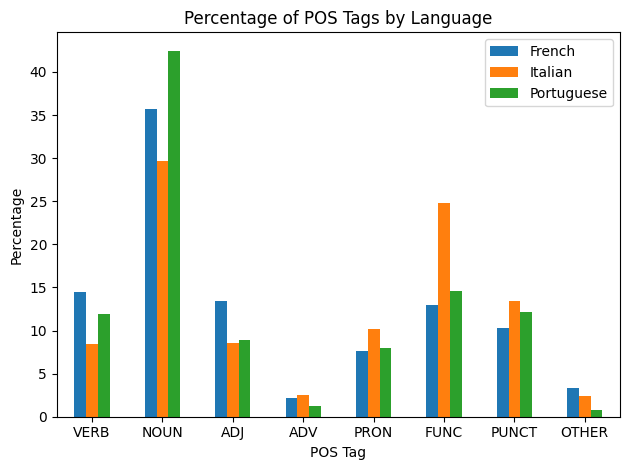

In [9]:
plt.figure(figsize=(10, 6))
plt.grouped_bar = overall_df[['FRENCH_PERCENTAGE', 'ITALIAN_PERCENTAGE', 'PORTUGUESE_PERCENTAGE']].plot(kind='bar')
plt.title('Percentage of POS Tags by Language')
plt.xlabel('POS Tag')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['French', 'Italian', 'Portuguese'])
plt.tight_layout()
plt.show()